# Dex Orderflow Correlation

 This notebook analayzes buy vs sell behavior in the USDC/WETH Uniswap v3 pool using decoded on-chain swap data. We construct a signed trade series (+1 for buys and -1 for sells), examine its distribution and compute transition probabilities and autocorrelations to measure how persistent order flow is. Persistent signed orderflow is a known empirical regularity. We can connect on-chain flow clustering to informed trading, routing behavior and potential LP risk and LVR

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

In [113]:
swaps = pd.read_parquet("../data/processed/usdcweth_swaps.parquet")

In [114]:
countBuy = sum(swaps["amount0"].astype(float) > 0)
countSell = sum(swaps["amount0"].astype(float) <0)
count = sum(swaps["amount0"].astype(float) ==0)

In [115]:
print(countBuy)
print(countSell)
print(count)

212551
224103
31


## Total buys and sells 
- (1 = buying WETH with USDC, -1 = selling WETH for USDC)

In [116]:
swaps["side"] = np.where(swaps["amount0"].astype(float) < 0, 1, -1)

In [117]:
counts = swaps["side"].value_counts()
print(counts)

side
 1    224103
-1    212582
Name: count, dtype: int64


## Now we can determine probs

In [118]:
probs = swaps["side"].value_counts(normalize=True)
print(probs)

side
 1    0.513191
-1    0.486809
Name: proportion, dtype: float64


- In this one pool, over the 2 year timeframe, there is a higher probability that a swap was a buy

## Now lets look at transitions between consecutive swaps

In [119]:
side_map = {1: "BuyWETH", -1: "SellWETH"}

In [120]:
swaps["side_next"] = swaps["side"].shift(-1)

In [121]:
transitions = swaps.dropna(subset=["side_next"]).copy()
transitions["side_next"] = transitions["side_next"].astype(int)

In [122]:
tm = pd.crosstab(
    transitions["side"],
    transitions["side_next"],
    normalize="index"
)
tm.index = [side_map[s] for s in tm.index]
tm.columns = [side_map[s] for s in tm.columns]
print(tm)

          SellWETH   BuyWETH
SellWETH  0.656987  0.343013
BuyWETH   0.325382  0.674618


- As expected we see sells are more likely to follow sells and buys are more likely to follow buys

## Autocorrelation of trade sign 

In [123]:
swaps["side"].autocorr(lag=1)

0.33160554633977085

## Distribution of run lengths

In [124]:
swaps = swaps.sort_values("block_timestamp").copy()
swaps["run_id"] =  (swaps["side"] != swaps["side"].shift()).cumsum()
run_lengths = swaps.groupby(["run_id", "side"]).size().reset_index(name="len")

In [125]:
print(run_lengths)

       run_id  side  len
0           1     1    3
1           2    -1    2
2           3     1    1
3           4    -1    1
4           5     1    4
...       ...   ...  ...
75885   75886    -1    2
75886   75887     1    1
75887   75888    -1    6
75888   75889     1    3
75889   75890    -1   26

[75890 rows x 3 columns]


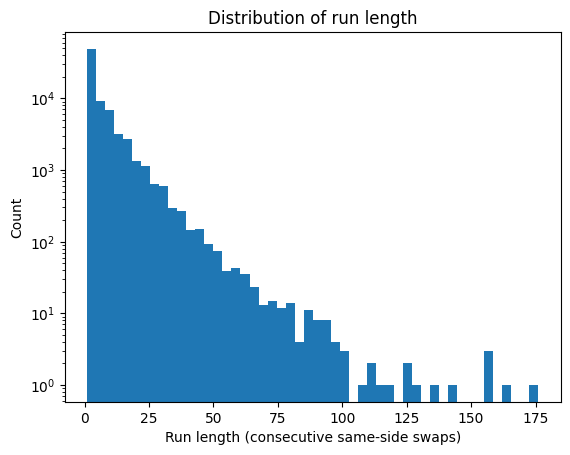

In [126]:
plt.figure()
plt.hist(run_lengths["len"], bins=50)
plt.xlabel("Run length (consecutive same-side swaps)")
plt.ylabel("Count")
plt.title("Distribution of run length")
plt.yscale("log")
plt.show()

In [127]:
plt.savefig("../figures/Distribution_run_length.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

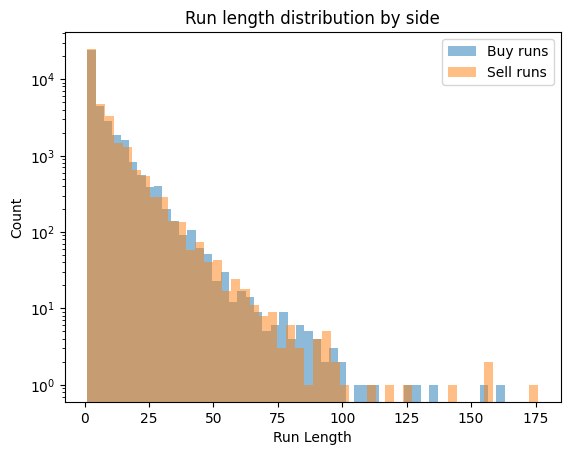

In [128]:
buy_runs = run_lengths[run_lengths["side"] ==1]["len"]
sell_runs = run_lengths[run_lengths["side"] ==-1]["len"]

plt.figure()
plt.hist(buy_runs, bins=50, alpha=0.5, label="Buy runs")
plt.hist(sell_runs, bins=50, alpha=0.5, label="Sell runs")
plt.xlabel("Run Length")
plt.ylabel("Count")
plt.yscale("log")
plt.legend()
plt.title("Run length distribution by side")
plt.show()

In [129]:
plt.savefig("../figures/Distribution_run_length_by_side.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [130]:
print(run_lengths["len"].max())

176


wow

In [131]:
run_lengths["len"].sum() == len(swaps)

True